In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as ex


In [2]:
customers=pd.read_csv("data-visualization/cleaned_customer_level_master_table.csv")
orders=pd.read_csv("data-visualization/cleaned_master_order_table.csv")
sellers=pd.read_csv("data-visualization/cleaned_seller_level_master_table.csv")
market_funnel=pd.read_csv("data-visualization/cleaned_seller_level_master_table.csv")
category=pd.read_csv("data-visualization/cleaned_category_level_master_table.csv")
customer_reviews=pd.read_csv("data_cleaning/processed_customer_reviews.csv")


# How Market Place is Currently Performing?
### Order analysis

In [8]:
total_orders = orders['order_id'].nunique()
total_customers = customers['customer_unique_id'].nunique()
total_sellers = sellers['seller_id'].nunique()
gmv = orders['total_item_value'].sum()
freight = orders['total_freight_value'].sum()
aov = orders['payment_value_total'].mean()

print(f"Total orders:            {total_orders:,}")
print(f"Total customers:         {total_customers:,}")
print(f"Total active sellers:    {total_sellers:,}")
print(f"GMV (item value):        R${gmv:,.2f}")
print(f"Total freight collected: R${freight:,.2f}")
print(f"Average order value:     R${aov:,.2f}")
print(f"Date range:              {orders['order_purchase_timestamp'].min()} -> {orders['order_purchase_timestamp'].max()}")
print()
print("Order status breakdown:")
print(orders['order_status'].value_counts())
print()
print(f"Marketplace-wide late-delivery rate: {orders['late_delivery_flag'].mean()*100:.2f}%")
print(f"Marketplace-wide average review score: {orders['review_score'].mean():.2f} / 5")
print(f"Average actual delivery time: {orders['actual_delivery_days'].mean():.1f} days")


Total orders:            95,830
Total customers:         96,096
Total active sellers:    3,095
GMV (item value):        R$13,109,390.63
Total freight collected: R$2,181,332.34
Average order value:     R$159.59
Date range:              2016-09-15 12:16:38 -> 2018-08-29 15:00:37

Order status breakdown:
order_status
delivered    95824
canceled         6
Name: count, dtype: int64

Marketplace-wide late-delivery rate: 6.66%
Marketplace-wide average review score: 4.16 / 5
Average actual delivery time: 12.1 days


### Customer Retention

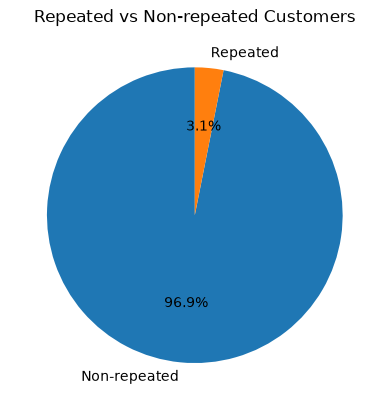

In [4]:
# Count repeated and non-repeated customers
repeated = (customers['customer_orders'] > 1).sum()
non_repeated = (customers['customer_orders'] == 1).sum()

# Plot
plt.pie(
    [non_repeated, repeated],
    labels=['Non-repeated', 'Repeated'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Repeated vs Non-repeated Customers')
plt.show()

The initial customer analysis revealed a significant gap between one-time and repeat customers on the e-commerce platform. Only 3.1% of customers placed more than one order, while 96.9% made a single purchase. This indicates that although the platform is successful in acquiring customers, converting these customers into repeat buyers remains a significant challenge.

This finding raises an important business question:

Why are such a large proportion of customers not returning to the platform?

Several factors may influence repeat purchasing behavior, including delivery delays, product quality, product condition, returns and refunds, packaging, and overall customer experience. To investigate these potential drivers, the analysis was extended from transactional customer data to customer feedback and review data.

primary_topic
Other                       1841
Delivery Delay               915
Product Condition/Damage     808
Product Quality              397
Return/Refund                365
Positive Experience          292
Product Description          263
Shipping/Logistics           221
Packaging                    100
Size/Fit                      87
Product Functionality         81
Delivery Speed                77
Price/Value                   77
Seller Service                52
Customer Service              16
Name: count, dtype: int64


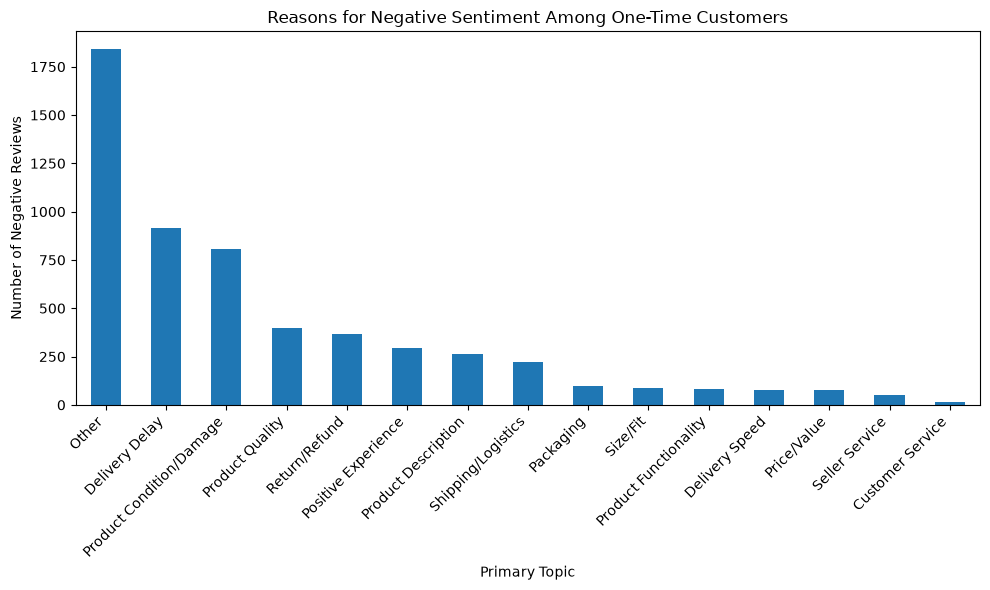

In [5]:
 # 1. Get customers who placed only 1 order
one_time_customers = customers[
    customers['customer_orders'] == 1
][['customer_unique_id']]

# 2. Get their orders
one_time_orders = orders.merge(
    one_time_customers,
    on='customer_unique_id',
    how='inner'
)

# 3. Get their reviews
one_time_reviews = one_time_orders.merge(
    customer_reviews[['order_id', 'primary_topic', 'sentiment']],
    on='order_id',
    how='inner'
)

# 4. Keep only negative reviews
negative_reviews = one_time_reviews[
    one_time_reviews['sentiment']
    .astype(str)
    .str.strip()
    .str.lower() == 'negative'
]

# 5. Count negative reviews by topic
topic_counts = negative_reviews['primary_topic'].value_counts()

print(topic_counts)

# 6. Plot
plt.figure(figsize=(10, 6))
topic_counts.plot(kind='bar')

plt.xlabel('Primary Topic')
plt.ylabel('Number of Negative Reviews')
plt.title('Reasons for Negative Sentiment Among One-Time Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Customer Feedback Preparation

The customer review dataset contains valuable qualitative information about customers' experiences. However, the review comments were primarily written in Portuguese, which required additional preprocessing before performing text-based analysis.

The following steps were therefore performed:

1. Review text preprocessing was performed to prepare the review data for analysis.
2. Portuguese review titles and messages were translated into English to enable consistent text analysis.
3. The translated title and review message were combined into a single review text field.
4. Sentiment analysis was performed to classify customer feedback based on its overall sentiment.
5. Topic classification was performed to identify the major themes discussed by customers.
6. A consolidated review dataset was created containing fields such as:
order_id
review_id
review_comment_title_en
review_comment_message_en
review_text_combined
sentiment
primary_topic

This transformed the original unstructured customer feedback into a structured dataset that could be used for further analysis.

### From Customer Retention to Customer Experience

The next stage of the analysis focuses specifically on one-time customers, as they represent the largest portion of the customer base.

Rather than simply examining the overall sentiment distribution, the analysis investigates:

**What are dissatisfied one-time customers complaining about?**

This helps connect customer feedback with potential barriers to repeat purchases.

### Negative Feedback Among One-Time Customers

The analysis of negative reviews from one-time customers highlights several recurring areas of dissatisfaction. Other, delivery delay, product condition/damage, product quality, and return/refund-related issues emerge as prominent themes in negative feedback.

This suggests that customers' post-purchase experience may play an important role in their decision to return to the platform. In particular, delivery reliability and product-related issues appear as important areas requiring further investigation.

However, the presence of these complaints does not by itself establish that they caused customers not to return. Therefore, the subsequent analysis examines whether these factors are associated with differences in customer satisfaction, delivery performance, and repeat purchasing behavior.

# Analysis of Delievery 

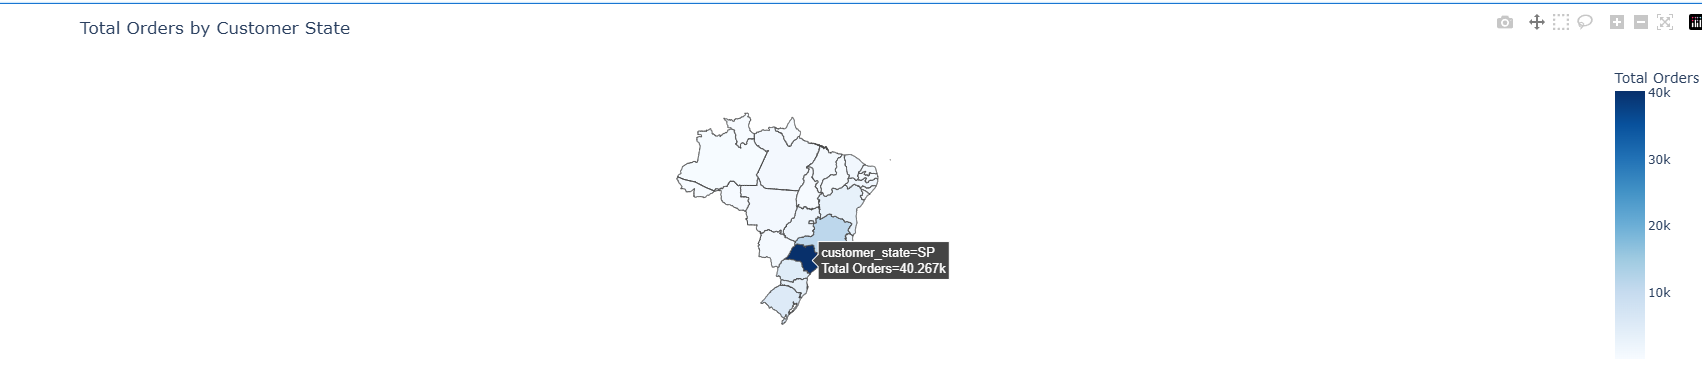
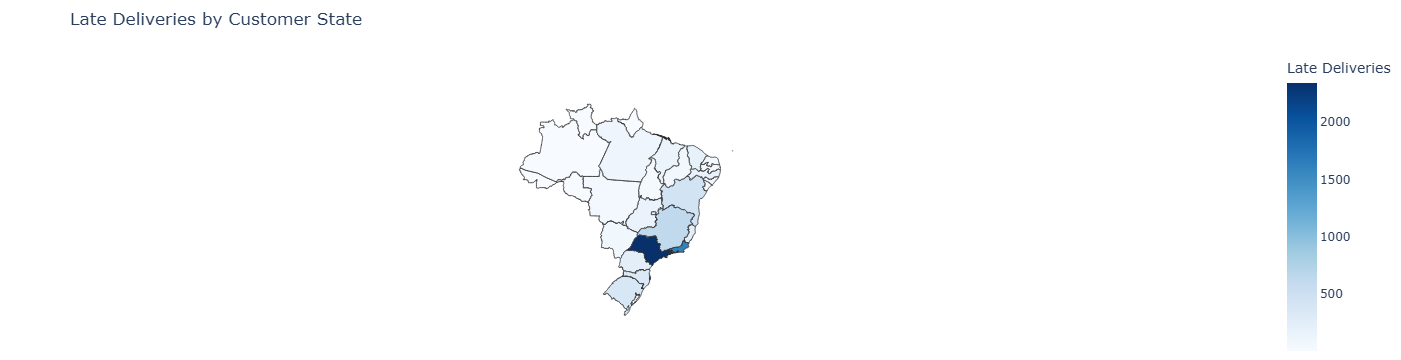 

From fig-__, we found that SP state has highest number of late deliveries which is significantly higher as compared to other states. The difference is also obvious as SP state has highest volume of total delieveries as well. 
So we plotted a graph that depicts the late delievery rate out of the total delieveries per state.

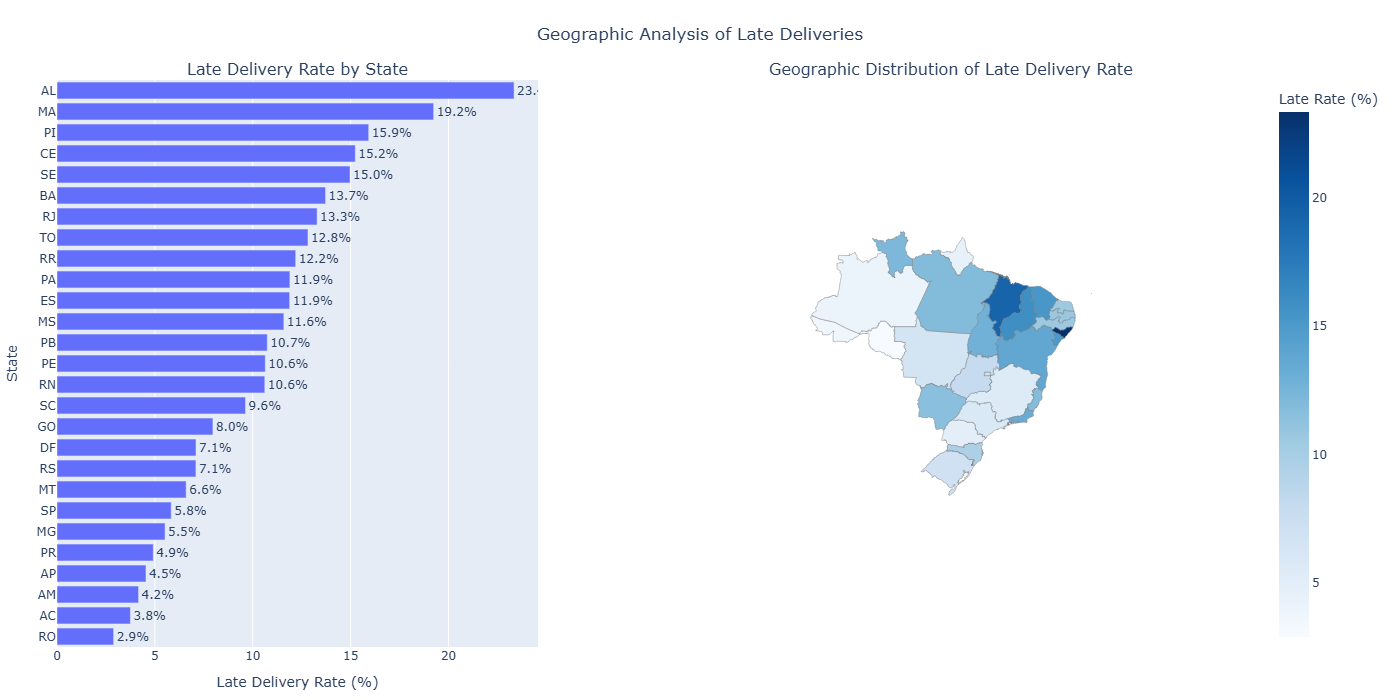


After analyzing delivery performance across states, a clear difference emerges between delivery volume and delivery reliability. AL has the highest late-delivery rate at approximately 23%, meaning nearly one in every four deliveries in the state is delivered late. This makes AL a clear area of concern from a customer-experience perspective, even though its overall order volume is much smaller than states such as SP.

In contrast, SP handles by far the largest order volume (approximately 40K orders), yet its late-delivery rate is only around 5.8%. This is an important finding: despite handling a very large number of orders, SP is able to maintain a comparatively low proportion of late deliveries. Therefore, the data does not suggest that SP is currently suffering from an order-overload problem. Instead, SP appears to be managing its high order volume relatively efficiently.

The comparison between AL and SP highlights an important distinction. AL has a delivery-reliability problem, while SP has a delivery-scale challenge. For AL, the priority should be understanding why such a high proportion of orders are arriving late. For SP, the focus should be on maintaining its current delivery performance as order volumes remain high.

Looking at absolute late deliveries adds another layer to the story. States with large order volumes can still generate a substantial number of late deliveries even when their late-delivery rate is relatively low. Therefore, management should not focus only on the states with the highest late-delivery percentages. The most useful approach is to consider both the late-delivery rate and the number of orders handled by each state.

Overall, the geographic analysis suggests that the company is facing two different delivery challenges: improving reliability in high-late-rate states such as AL, while protecting the operational efficiency of high-volume markets such as SP. This distinction can help the business avoid applying the same solution to every region and instead target the underlying problem in each state.

### Seller Analysis
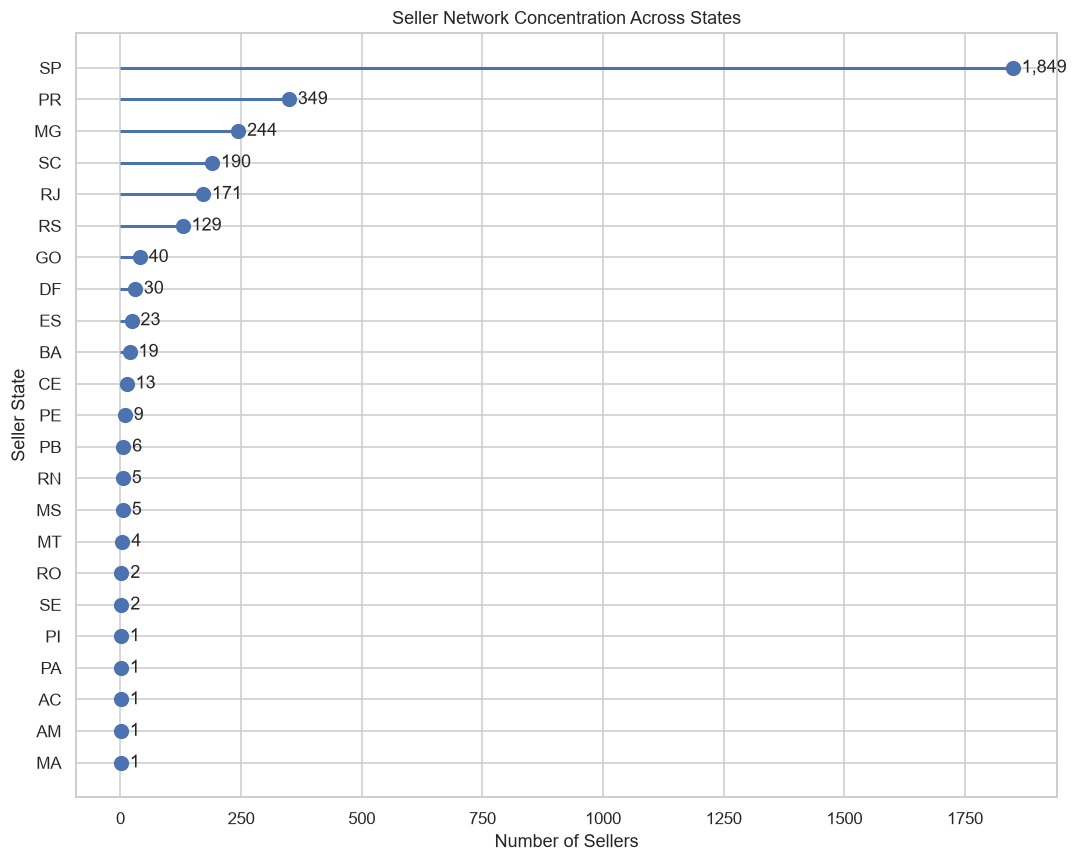